# Matched-start analysis: from raw traces to a stop threshold

Several batches share the same starting layouts — one with no random movement, the others with it.
The no-randomness batch is the **reference**: it disperses to a plateau under separation alone, and
that plateau area `A*(R)` becomes the stop condition for the randomised runs. Every clip then ends
at the same degree of dispersion, so randomness changes the *manner* of the motion rather than how
far the swarm got.

This notebook walks the whole chain, with the evidence at each step:

| Step | Question | Section |
|---|---|---|
| Raw data | What do the runs actually look like? | 2, 3 |
| Pairing | Do the batches really share starts? | 4 |
| Convergence | Did the reference settle, and did the others? | 5 |
| A*(R) | What dispersion does separation alone reach? | 6 |
| Crossing | When do randomised runs reach it, and reliably? | 7 |
| Walls | Is the endpoint set by the swarm or by the arena? | 8 |
| Decision | Which radius, and what to set in Unity | 9 |

**Kernel:** `Python (PythonAnalysis)`.

In [ ]:
import sys
from pathlib import Path
from collections import defaultdict

ANALYSIS = Path.cwd().parent
if str(ANALYSIS) not in sys.path:
    sys.path.insert(0, str(ANALYSIS))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

import steady_state as ss
import matched_start as msa

PARENT  = ANALYSIS.parent / "Assets/SimulationRecordings/Combinations/20260825_014231"
BUDGET  = 0.20      # fraction of agents allowed to have touched a wall
DWELL   = 0.5       # seconds the threshold must hold, matching Unity
MAXSPEED = 1.5      # which max speed to analyse; A* differs by speed

batches = msa.discover_batches(PARENT)
runs_by_cond = {(b["random"], b["maxSpeed"]): b["runs"] for b in batches.values()}
conditions = sorted(runs_by_cond, key=lambda k: (k[1], k[0]))

RADII = sorted({round(r["perceptionRadius"], 2) for r in next(iter(runs_by_cond.values()))})
LAYOUTS = sorted({r["header"]["spawnLayoutId"] for r in next(iter(runs_by_cond.values()))})

print(f"{len(batches)} batches, {sum(len(v) for v in runs_by_cond.values())} clips total")
for (rnd, ms) in conditions:
    print(f"   random {rnd:>3}  maxSpeed {ms:>3}  {len(runs_by_cond[(rnd, ms)])} clips")
print(f"\nperception radii: {RADII}")
print(f"layouts: {len(LAYOUTS)}")

COLOUR = {c: plt.cm.viridis(i / max(len(conditions) - 1, 1)) for i, c in enumerate(conditions)}
def label(c): return f"random {c[0]}, ms {c[1]:g}"


def runs_at(cond, R):
    return [r for r in runs_by_cond[cond] if abs(r["perceptionRadius"] - R) < 1e-6]


def mean_series(runs, n=400):
    """Resample runs onto a common time grid and return mean, min, max."""
    tmax = min(float(r["times"][-1]) for r in runs)
    grid = np.linspace(0, tmax, n)
    stack = np.array([np.interp(grid, r["times"], r["areas"]) for r in runs])
    return grid, stack.mean(0), stack.min(0), stack.max(0)


def mean_walls(runs, n=400):
    tmax = min(float(r["times"][-1]) for r in runs)
    grid = np.linspace(0, tmax, n)
    N = max(int(runs[0]["header"].get("agentCount", 1)), 1)
    stack = np.array([np.interp(grid, r["times"], r["unique"]) / N for r in runs])
    return grid, stack.mean(0), stack.min(0), stack.max(0)

## 2. Raw hull area over time

Everything downstream is derived from this. One panel per perception radius, one line per
condition, averaged over the five layouts with the spread shaded.

Read it as: how far does the swarm spread, how fast, and does it stop?

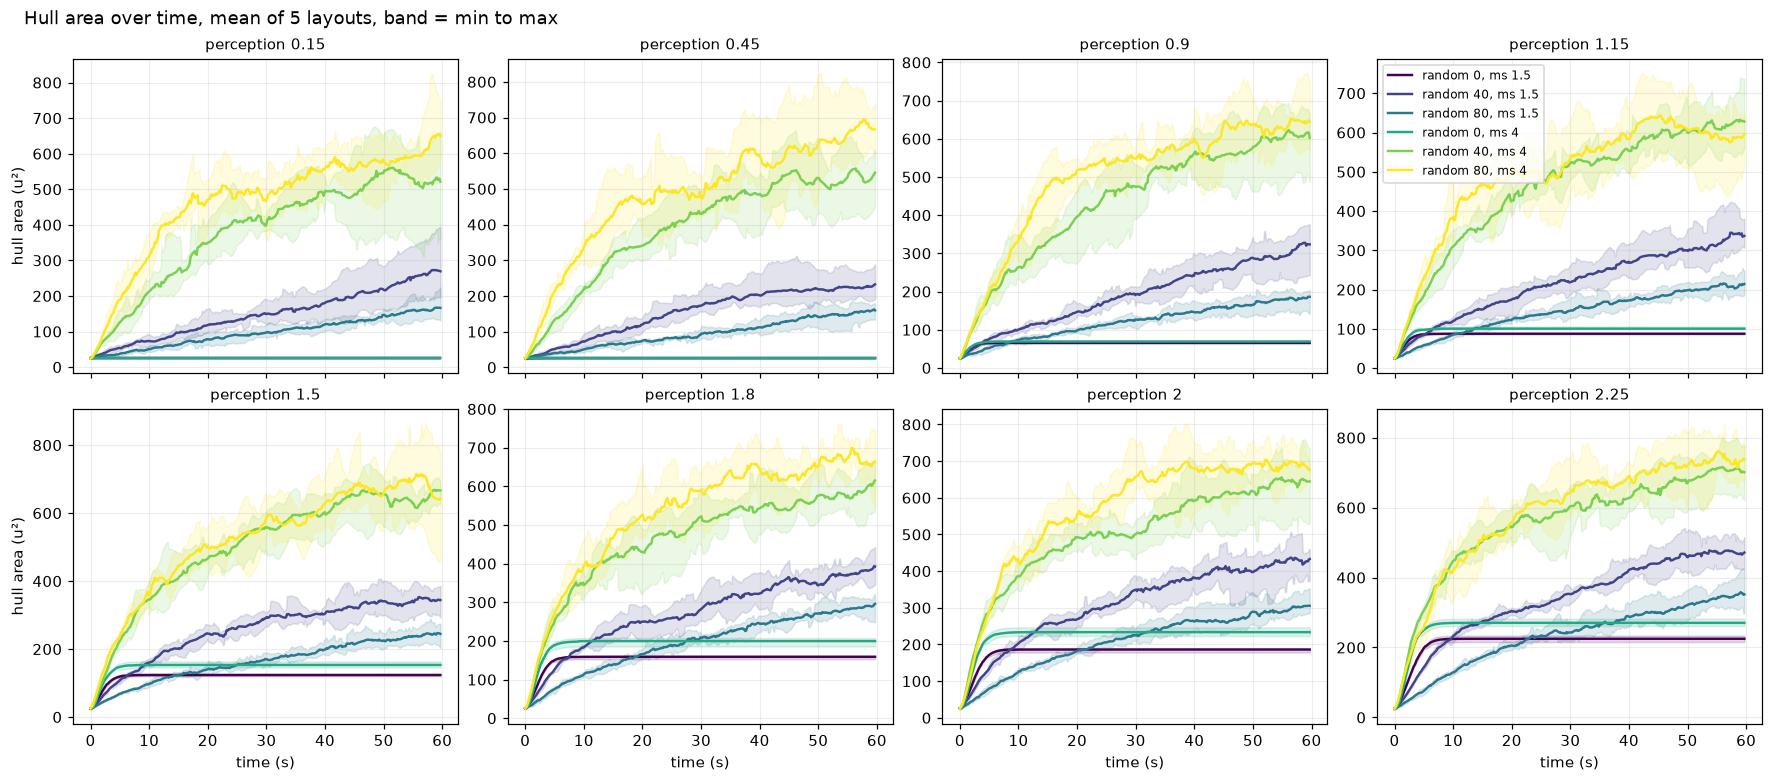

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, layout="constrained")

for ax, R in zip(axes.ravel(), RADII):
    for c in conditions:
        rs = runs_at(c, R)
        if not rs:
            continue
        t, m, lo, hi = mean_series(rs)
        ax.plot(t, m, color=COLOUR[c], linewidth=1.6, label=label(c))
        ax.fill_between(t, lo, hi, color=COLOUR[c], alpha=0.15)

    ax.set_title(f"perception {R:g}", fontsize=10)
    ax.grid(alpha=0.22)

for ax in axes[:, 0]:
    ax.set_ylabel("hull area (u²)")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")

axes[0, -1].legend(fontsize=8)
fig.suptitle("Hull area over time, mean of 5 layouts, band = min to max", fontsize=12, ha="left", x=0.01)
plt.show()

### What to notice

The zero-randomness runs rise and then flatten — that flat value is what the whole method rests on.
The randomised runs climb higher and keep climbing; whether they ever flatten is checked in
section 5.

## 3. Raw wall contacts over time

The other half of the raw data: what fraction of the swarm has touched a wall by each moment. This
is what separates a dispersion the swarm chose from one the arena imposed.

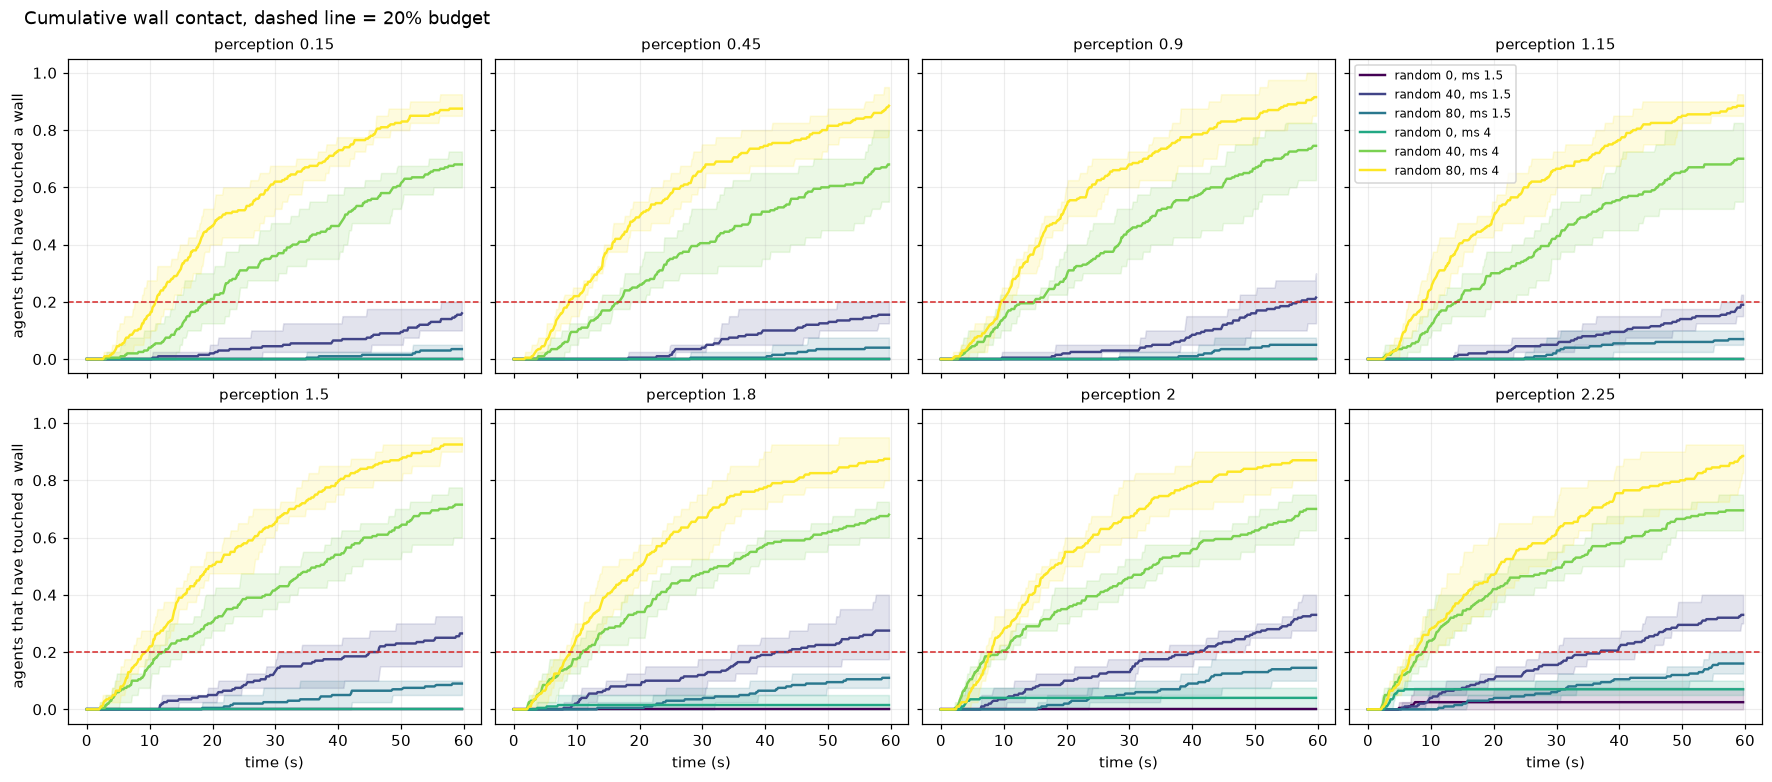

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True, layout="constrained")

for ax, R in zip(axes.ravel(), RADII):
    for c in conditions:
        rs = runs_at(c, R)
        if not rs:
            continue
        t, m, lo, hi = mean_walls(rs)
        ax.plot(t, m, color=COLOUR[c], linewidth=1.6, label=label(c))
        ax.fill_between(t, lo, hi, color=COLOUR[c], alpha=0.15)

    ax.axhline(BUDGET, color="#d62728", linestyle="--", linewidth=1)
    ax.set_title(f"perception {R:g}", fontsize=10)
    ax.grid(alpha=0.22)

for ax in axes[:, 0]:
    ax.set_ylabel("agents that have touched a wall")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")

axes[0, -1].legend(fontsize=8)
fig.suptitle(f"Cumulative wall contact, dashed line = {BUDGET:.0%} budget",
             fontsize=12, ha="left", x=0.01)
plt.show()

## 4. Are the starts really shared?

If they are not, the differences above include spawn variation and none of the comparisons are
paired. Three checks, in increasing strictness: the fingerprints recorded in every clip, the saved
layout files against the first recorded frame, and the positions plotted directly.

Note the first *recorded* frame is not quite the spawn: capture begins a few frames after motion
starts, so a randomised run has already been nudged by then. Section 4b measures that drift.

In [ ]:
paired = msa.layout_report(batches)

1. LAYOUT INTEGRITY

   20260825_014231 [Dispersion r0 ms1.5]: 65 clips, 5 layouts, each layout identical across its clips
   20260825_014231 [Dispersion r0 ms4]: 65 clips, 5 layouts, each layout identical across its clips
   20260825_014231 [Dispersion r40 ms1.5]: 65 clips, 5 layouts, each layout identical across its clips
   20260825_014231 [Dispersion r40 ms4]: 65 clips, 5 layouts, each layout identical across its clips
   20260825_014231 [Dispersion r80 ms1.5]: 65 clips, 5 layouts, each layout identical across its clips
   20260825_014231 [Dispersion r80 ms4]: 65 clips, 5 layouts, each layout identical across its clips

   5 distinct layouts across all batches, 5 shared by every batch
   -> starts match across batches, the comparison is paired


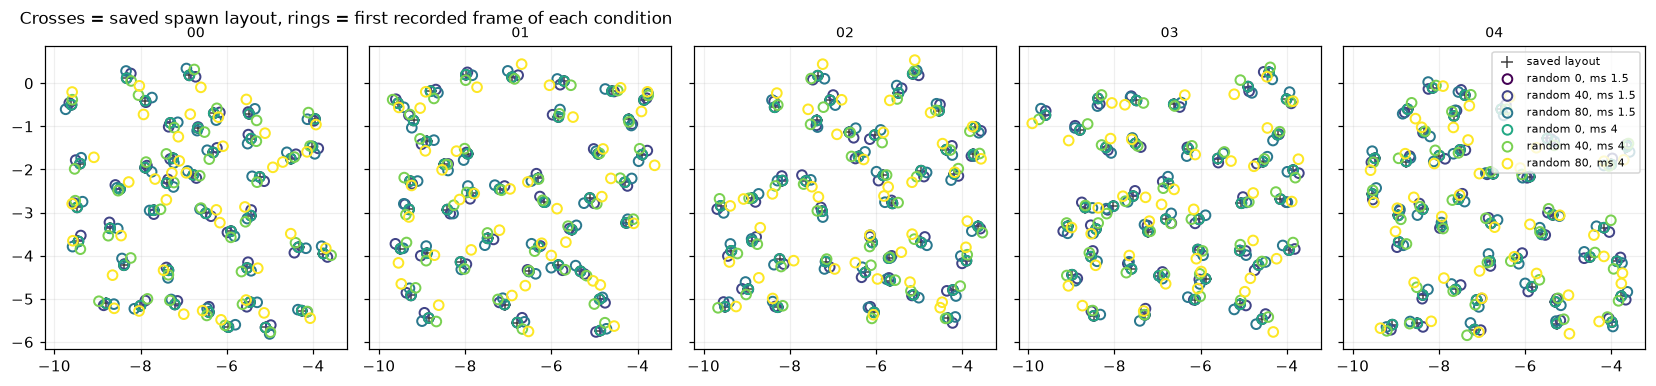

In [ ]:
import json as _json

LAYOUT_DIR = ANALYSIS.parent / "Assets/SimulationRecordings/SpawnLayouts"
saved = {}
for p in LAYOUT_DIR.glob("*.json"):
    d = _json.loads(p.read_text())
    saved[d["layoutId"]] = np.array(d["positions"], dtype=float).reshape(-1, 2)

fig, axes = plt.subplots(1, len(LAYOUTS), figsize=(3.0 * len(LAYOUTS), 3.3),
                         sharex=True, sharey=True, layout="constrained")

for ax, layout in zip(np.atleast_1d(axes), LAYOUTS):
    if layout in saved:
        ax.scatter(saved[layout][:, 0], saved[layout][:, 1], s=70, marker="+",
                   color="#444444", linewidths=1.0, label="saved layout", zorder=1)

    for c in conditions:
        run = next((r for r in runs_at(c, RADII[0])
                    if r["header"]["spawnLayoutId"] == layout), None)
        if run is None:
            continue
        first = np.asarray(_json.loads(run["path"].read_text())["frames"][0]["v"],
                           dtype=float).reshape(-1, 5)[:, :2]
        ax.scatter(first[:, 0], first[:, 1], s=40, facecolors="none",
                   edgecolors=COLOUR[c], linewidths=1.3, label=label(c), zorder=2)

    ax.set_title(layout.split("_layout_")[-1], fontsize=9)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

np.atleast_1d(axes)[-1].legend(fontsize=7)
fig.suptitle("Crosses = saved spawn layout, rings = first recorded frame of each condition",
             fontsize=11, ha="left", x=0.01)
plt.show()

### 4b. How far do agents move before the first recorded frame?

Capture starts after motion is enabled, so the opening frame is a moment *after* the spawn. With no
randomness nothing has moved. With randomness the immediate kick displaces agents slightly, which
is why the rings above do not sit exactly on the crosses.

What matters is the size of it relative to the effect being measured.

In [ ]:
drift = []
for c in conditions:
    for layout in LAYOUTS:
        run = next((r for r in runs_at(c, RADII[0])
                    if r["header"]["spawnLayoutId"] == layout), None)
        if run is None or layout not in saved:
            continue
        first = np.asarray(_json.loads(run["path"].read_text())["frames"][0]["v"],
                           dtype=float).reshape(-1, 5)[:, :2]
        d = np.linalg.norm(first - saved[layout], axis=1)
        drift.append({"random": c[0], "maxSpeed": c[1], "layout": layout.split("_layout_")[-1],
                      "mean_drift_u": round(float(d.mean()), 3),
                      "max_drift_u": round(float(d.max()), 3),
                      "hull_at_frame0": round(float(run["areas"][0]), 1)})

drift = pd.DataFrame(drift)
summary = drift.groupby(["random", "maxSpeed"]).agg(
    mean_drift_u=("mean_drift_u", "mean"),
    max_drift_u=("max_drift_u", "max"),
    hull_at_frame0=("hull_at_frame0", "mean")).round(3)

print("agent radius 0.156 u, spawn area about 6 u across\n")
print(summary.to_string())
print()
print("The spawn positions themselves are identical, proven by the fingerprints and by the")
print("zero drift in the reference runs. The randomised runs start recording a few frames later")
print("in effect, which is small next to the dispersion being measured but worth stating.")
summary

agent radius 0.156 u, spawn area about 6 u across

                 mean_drift_u  max_drift_u  hull_at_frame0
random maxSpeed                                           
0      1.5              0.000        0.001           24.88
       4.0              0.000        0.001           24.88
40     1.5              0.120        0.164           25.38
       4.0              0.141        0.245           24.94
80     1.5              0.157        0.186           24.60
       4.0              0.265        0.394           24.08

The spawn positions themselves are identical, proven by the fingerprints and by the
zero drift in the reference runs. The randomised runs start recording a few frames later
in effect, which is small next to the dispersion being measured but worth stating.


mean_drift_u  max_drift_u  hull_at_frame0
random maxSpeed                                           
0      1.5              0.000        0.001           24.88
       4.0              0.000        0.001           24.88
40     1.5              0.120        0.164           25.38
       4.0              0.141        0.245           24.94
80     1.5              0.157        0.186           24.60
       4.0              0.265        0.394           24.08

## 5. Did the runs converge?

A plateau taken from a run that was still expanding when time ran out is not a plateau, it is just
wherever it got to. Only the reference has to converge, but knowing which did matters for how the
numbers are read.

In [ ]:
_ = msa.convergence_report(batches)



2. CONVERGENCE

   batch                   random  maxSpeed     R range  settled  plateau at  growth in last 20%
   20260825_014231 [Dispersion r0 ms1.5]       0       1.5    0.15-3.5    100%        6.8s               0.0%
   20260825_014231 [Dispersion r0 ms4]       0       4.0    0.15-3.5    100%        6.2s               0.0%
   20260825_014231 [Dispersion r40 ms1.5]      40       1.5    0.15-3.5     49%       41.2s               4.4%
   20260825_014231 [Dispersion r40 ms4]      40       4.0    0.15-3.5     71%       36.7s               2.4%
   20260825_014231 [Dispersion r80 ms1.5]      80       1.5    0.15-3.5     42%       47.3s               5.9%
   20260825_014231 [Dispersion r80 ms4]      80       4.0    0.15-3.5     12%       57.0s               2.9%

   A batch well below 100% never reached steady state. Its own plateau is not
   meaningful, but it can still be compared against a reference that did converge.


### How the plateau is detected

The rolling slope must stay under a tolerance for a sustained period. Shown on one reference run
so the criterion is visible rather than asserted.

{'path': PosixPath('/Users/cyrusjackson/Documents/Dev/Repos/SwarmRoboticsPerception/Assets/SimulationRecordings/Combinations/20260825_014231/type_dispersion_randommovement_0.00_perceptionrad_2.50_maxspeed_1.50_20260819_150007_layout_00.json'), 'header': {'fileName': 'type_dispersion_randommovement_0.00_perceptionrad_2.50_maxspeed_1.50_20260819_150007_layout_00', 'sceneName': 'Scene6_Replay_Expand', 'recordedAtUtc': '2026-08-25 01:44:17', 'swarmType': 'Dispersion', 'agentCount': 40, 'requestedAgentCount': 40, 'agentSpawnShortfall': False, 'frameCount': 3582, 'duration': 59.68359375, 'captureHz': 0.0, 'contactsRecorded': True, 'contactDistance': 0.17599999904632568, 'agentRadius': 0.15600000321865082, 'spawnLayoutId': '20260819_150007_layout_00', 'spawnLayoutFingerprint': '75E2CCAE', 'hullAreaRecorded': True, 'hullTrimFraction': 0.10000000149011612, 'agentNames': ['Agent_000', 'Agent_001', 'Agent_002', 'Agent_003', 'Agent_004', 'Agent_005', 'Agent_006', 'Agent_007', 'Agent_008', 'Agent_0

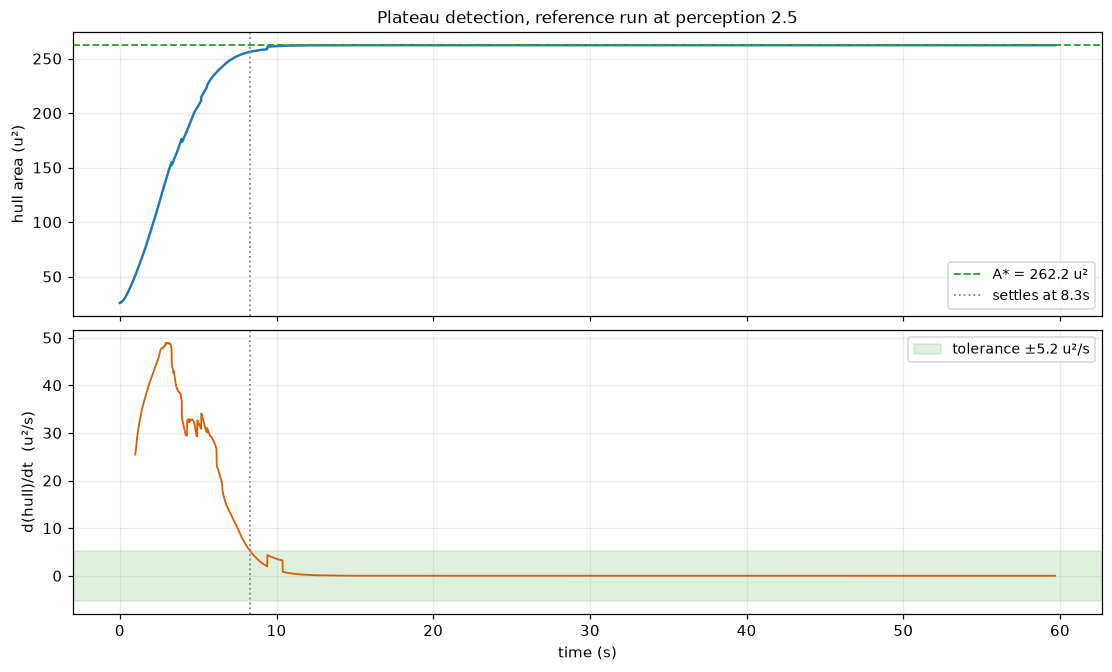

In [ ]:
demo = runs_at((0, MAXSPEED), RADII[8])[0]
print(demo)
info = ss.find_plateau(demo["times"], demo["areas"])

dt = float(np.median(np.diff(demo["times"])))
w = max(2, int(round(1.0 / dt)))
slope = np.full(len(demo["areas"]), np.nan)
slope[w:] = (demo["areas"][w:] - demo["areas"][:-w]) / (demo["times"][w:] - demo["times"][:-w])
tol = 0.02 * demo["areas"].max()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")

a1.plot(demo["times"], demo["areas"], color="#1f77b4", linewidth=1.6)
a1.axhline(info["area"], color="#2ca02c", linestyle="--", linewidth=1.2,
           label=f"A* = {info['area']:.1f} u²")
a1.axvline(info["time"], color="#888888", linestyle=":", linewidth=1.2,
           label=f"settles at {info['time']:.1f}s")
a1.set_ylabel("hull area (u²)"); a1.grid(alpha=0.25); a1.legend(fontsize=9)
a1.set_title(f"Plateau detection, reference run at perception {demo['perceptionRadius']:g}", fontsize=11)

a2.plot(demo["times"], slope, color="#d95f02", linewidth=1.2)
a2.axhspan(-tol, tol, color="#2ca02c", alpha=0.15, label=f"tolerance ±{tol:.1f} u²/s")
a2.axvline(info["time"], color="#888888", linestyle=":", linewidth=1.2)
a2.set_ylabel("d(hull)/dt  (u²/s)"); a2.set_xlabel("time (s)")
a2.grid(alpha=0.25); a2.legend(fontsize=9)
plt.show()

## 6. A*(R): what separation alone achieves

The reference plateau against perception radius. This curve is the thing the thresholds come from,
and the error bars say how repeatable it is across the five starting layouts.

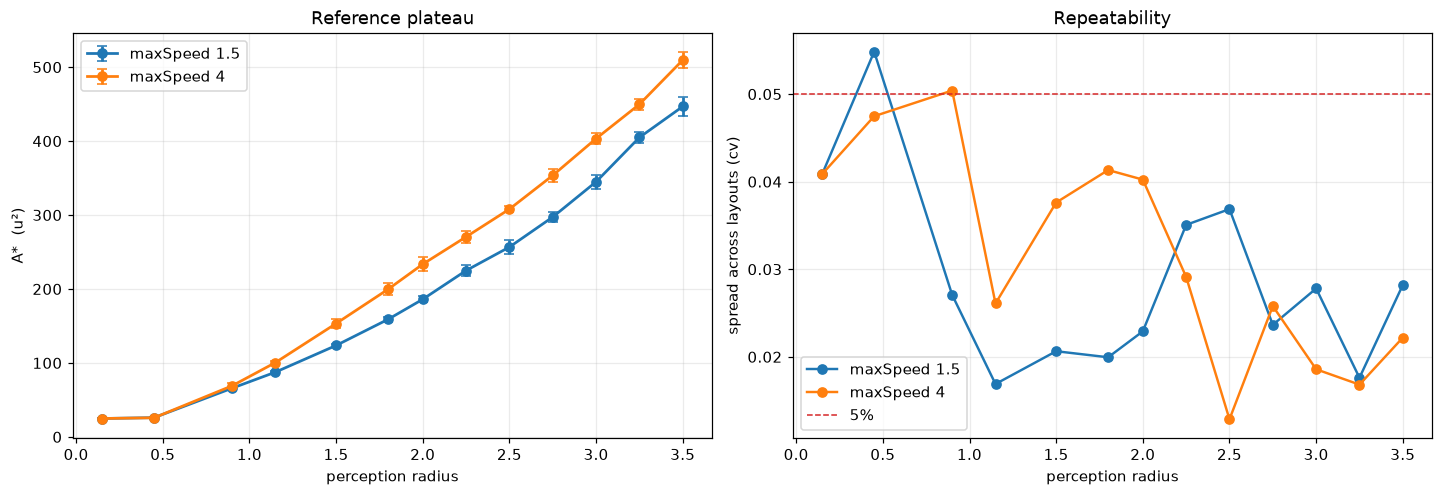

,A* at ms 1.5,A* at ms 4
perception,,
0.15,24.9,24.9
0.45,26.1,25.9
0.90,65.9,69.1
1.15,87.6,100.5
1.50,123.7,153.3
1.80,159.0,199.7
2.00,186.1,233.6
2.25,224.9,270.5
2.50,256.7,308.0


In [ ]:
refs = {b["maxSpeed"]: b for b in batches.values() if b["random"] == 0}
astar = {ms: msa.reference_areas(b["runs"]) for ms, b in refs.items()}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), layout="constrained")

for ms, table in sorted(astar.items()):
    R = list(table)
    a1.errorbar(R, [table[r]["mean"] for r in R], yerr=[table[r]["std"] for r in R],
                marker="o", capsize=3, linewidth=1.8, label=f"maxSpeed {ms:g}")
    a2.plot(R, [table[r]["cv"] for r in R], marker="o", linewidth=1.6, label=f"maxSpeed {ms:g}")

a1.set_xlabel("perception radius"); a1.set_ylabel("A*  (u²)")
a1.set_title("Reference plateau"); a1.grid(alpha=0.25); a1.legend()

a2.axhline(0.05, color="#d62728", linestyle="--", linewidth=1, label="5%")
a2.set_xlabel("perception radius"); a2.set_ylabel("spread across layouts (cv)")
a2.set_title("Repeatability"); a2.grid(alpha=0.25); a2.legend()
plt.show()

pd.DataFrame({ms: {r: round(v["mean"], 1) for r, v in t.items()} for ms, t in astar.items()}) \
  .rename_axis("perception").rename(columns=lambda c: f"A* at ms {c:g}")

## 7. When do the randomised runs reach A*?

This is the clip length the threshold would produce. A radius is only usable if it fires in
**every** layout, otherwise some conditions would run to the timeout instead.

In [ ]:
rows = msa.crossing_report(batches, BUDGET, DWELL)
table = pd.DataFrame(rows)
table[table["maxSpeed"] == MAXSPEED]

ValueError: too many values to unpack (expected 3)

In [ ]:
sub = table[table["maxSpeed"] == MAXSPEED]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), layout="constrained")

for rnd, g in sub.groupby("random"):
    g = g.sort_values("perception")
    ok = g.dropna(subset=["mean_cross_s"])
    a1.plot(ok["perception"], ok["mean_cross_s"], marker="o", linewidth=1.8, label=f"random {rnd:g}")
    a1.fill_between(ok["perception"], ok["min_cross_s"], ok["max_cross_s"], alpha=0.15)
    a2.plot(g["perception"], g["fired"] / g["of"], marker="s", linewidth=1.8, label=f"random {rnd:g}")

a1.set_xlabel("perception radius"); a1.set_ylabel("time to reach A* (s)")
a1.set_title("Resulting clip length, band = spread across layouts")
a1.grid(alpha=0.25); a1.legend()

a2.axhline(1.0, color="#2ca02c", linestyle="--", linewidth=1, label="fires in every layout")
a2.set_ylim(0, 1.1)
a2.set_xlabel("perception radius"); a2.set_ylabel("fraction of layouts where it fires")
a2.set_title("Reliability"); a2.grid(alpha=0.25); a2.legend()
plt.show()

## 8. Wall contact at the moment of crossing

The endpoint should be set by the swarm, not the arena. This is the check that it is.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")

for rnd, g in sub.groupby("random"):
    g = g.dropna(subset=["wall_fraction"]).sort_values("perception")
    ax.plot(g["perception"], g["wall_fraction"], marker="o", linewidth=1.8, label=f"random {rnd:g}")

ax.axhline(BUDGET, color="#d62728", linestyle="--", linewidth=1.2, label=f"budget {BUDGET:.0%}")
ax.set_xlabel("perception radius")
ax.set_ylabel("agents that had touched a wall, at crossing")
ax.set_ylim(0, max(BUDGET * 1.3, float(sub["wall_fraction"].max() or 0) * 1.3))
ax.set_title("Is the endpoint the swarm's doing or the arena's?")
ax.grid(alpha=0.25); ax.legend()
plt.show()

## 9. The decision

A radius is usable when it fires in every layout of every condition and stays inside the wall
budget. Both criteria shown together, then the traces at the chosen radius with the threshold
drawn on.

In [ ]:
crit = []
for R in RADII:
    g = sub[np.isclose(sub["perception"], R)]
    if g.empty:
        continue
    crit.append({
        "perception": R,
        "A*": round(astar[MAXSPEED][R]["mean"], 1),
        "cv": f"{astar[MAXSPEED][R]['cv']:.1%}",
        "fires everywhere": bool((g["fired"] == g["of"]).all()),
        "within budget": bool((g["wall_fraction"].fillna(0) <= BUDGET).all()),
        "slowest clip (s)": round(float(g["max_cross_s"].max()), 1) if g["max_cross_s"].notna().any() else None,
    })

decision = pd.DataFrame(crit)
decision["usable"] = decision["fires everywhere"] & decision["within budget"]
decision

In [ ]:
usable = decision[decision["usable"]]
R_PICK = float(usable["perception"].max()) if len(usable) else RADII[-1]
A_TARGET = astar[MAXSPEED][R_PICK]["mean"]
slowest = float(usable[usable["perception"] == R_PICK]["slowest clip (s)"].iloc[0]) if len(usable) else None

print(f"chosen perception radius : {R_PICK:g}")
print(f"target hull area A*      : {A_TARGET:.1f} u²")
print(f"slowest clip             : {slowest:.1f}s")
print()
print("Unity, on the Dispersion entry in SimRecorder:")
print(f"   end condition        Absolute Hull Area")
print(f"   Target Hull Area     {A_TARGET:.0f}")
print(f"   Dwell Before Ending  {DWELL:g}")
print(f"   Max Time Override    {np.ceil(slowest * 1.3):.0f}   (comfortably above the slowest crossing)")
print()
print(f"A* was measured at maxSpeed {MAXSPEED:g} and rises with speed, so it is only valid there.")

In [ ]:
fig, axes = plt.subplots(1, len(LAYOUTS), figsize=(3.1 * len(LAYOUTS), 3.6),
                         sharey=True, layout="constrained")

for ax, layout in zip(np.atleast_1d(axes), LAYOUTS):
    for c in [c for c in conditions if c[1] == MAXSPEED]:
        run = next((r for r in runs_at(c, R_PICK) if r["header"]["spawnLayoutId"] == layout), None)
        if run is None:
            continue
        ax.plot(run["times"], run["areas"], color=COLOUR[c], linewidth=1.5, label=label(c))

        cross = ss.crossing_time(run, A_TARGET, DWELL)
        if cross["fires"]:
            ax.plot(cross["time"], cross["area"], marker="v", markersize=8, color=COLOUR[c])

    ax.axhline(A_TARGET, color="#d62728", linestyle="--", linewidth=1.2)
    ax.set_title(layout.split("_layout_")[-1], fontsize=9)
    ax.set_xlabel("time (s)"); ax.grid(alpha=0.22)

np.atleast_1d(axes)[0].set_ylabel("hull area (u²)")
np.atleast_1d(axes)[-1].legend(fontsize=7)
fig.suptitle(f"Paired traces at perception {R_PICK:g}. Same start within each panel; "
             f"markers show where each clip would stop.", fontsize=11, ha="left", x=0.01)
plt.show()

## 10. Caveats worth carrying into the write-up

- **Duration varies by condition.** Holding the endpoint constant means clip length differs between
  randomness levels — visible to participants, so report it rather than leaving it implicit.
- **A\* depends on max speed.** It barely moves below perception 0.9 but rises steeply above it, so
  a reference is only valid for the speed it was measured at.
- **Nothing saturated here.** The reference was still climbing at the largest radius tested, so the
  usable range may extend further; the sweep can be widened.